In [1]:
import gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

np.bool8 = np.bool_

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Distributional RL

### C51

In [3]:
class C51Network(nn.Module):
    def __init__(self, obs_dim, n_actions, n_atoms):
        super(C51Network, self).__init__()
        self.n_actions = n_actions
        self.n_atoms = n_atoms
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions * n_atoms)
        )

    def forward(self, x):
        batch_size = x.size(0)
        logits = self.net(x)
        logits = logits.view(batch_size, self.n_actions, self.n_atoms)
        return logits

In [4]:
class C51AgentTorch:
    def __init__(self, obs_dim, n_actions, V_min=-200, V_max=200, n_atoms=51,
                 gamma=0.99, lr=2.5e-4, buffer_size=100_000,
                 batch_size=64, target_sync_every=5000):
        self.n_actions = n_actions
        self.V_min, self.V_max, self.n_atoms = V_min, V_max, n_atoms
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_sync_every = target_sync_every
        self.delta_z = (V_max - V_min) / (n_atoms - 1)
        self.z = torch.linspace(V_min, V_max, n_atoms).to(device)

        self.model = C51Network(obs_dim, n_actions, n_atoms).to(device)
        self.target_model = C51Network(obs_dim, n_actions, n_atoms).to(device)
        self.update_target()

        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.buffer = deque(maxlen=buffer_size)
        self.learn_steps = 0

    def update_target(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def remember(self, s, a, r, s_, done):
        self.buffer.append((s, a, r, s_, done))

    def sample_batch(self):
        batch = random.sample(self.buffer, self.batch_size)
        s, a, r, s_, d = zip(*batch)

        s = torch.FloatTensor(s).to(device)
        a = torch.LongTensor(a).to(device)
        r = torch.FloatTensor(r).to(device)
        s_ = torch.FloatTensor(s_).to(device)
        d = torch.FloatTensor(d).to(device)
        return s, a, r, s_, d

    def _l2_project(self, r, d, next_dist):
        batch_size = r.size(0)
        tz = r.unsqueeze(1) + self.gamma * (1 - d.unsqueeze(1)) * self.z
        tz = torch.clamp(tz, self.V_min, self.V_max)
        b = (tz - self.V_min) / self.delta_z
        l = b.floor().long()
        u = b.ceil().long()

        l = torch.clamp(l, 0, self.n_atoms - 1)
        u = torch.clamp(u, 0, self.n_atoms - 1)

        m = torch.zeros(batch_size, self.n_atoms).to(device)

        offset = torch.linspace(0, (batch_size - 1) * self.n_atoms, batch_size).long().unsqueeze(1).to(device)

        m.view(-1).index_add_(0, (l + offset).view(-1),
            (next_dist * (u.float() - b)).view(-1))
        m.view(-1).index_add_(0, (u + offset).view(-1),
            (next_dist * (b - l.float())).view(-1))
        m = m / m.sum(dim=1, keepdim=True)
        return m

    def train_step(self):
        if len(self.buffer) < 10000:
            return

        s, a, r, s_, d = self.sample_batch()

        # Predict next Q using online and target network
        with torch.no_grad():
            next_logits = self.model(s_)
            next_probs = torch.softmax(next_logits, dim=2)
            q_values = torch.sum(next_probs * self.z, dim=2)
            best_action = q_values.argmax(dim=1)

            next_target_logits = self.target_model(s_)
            next_target_probs = torch.softmax(next_target_logits, dim=2)
            next_dist = next_target_probs[range(self.batch_size), best_action]
            target_dist = self._l2_project(r, d, next_dist)

        logits = self.model(s)
        log_probs = torch.log_softmax(logits, dim=2)
        chosen_logits = log_probs[range(self.batch_size), a]

        loss = -(target_dist * chosen_logits).sum(dim=1).mean()
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.learn_steps += 1
        if self.learn_steps % self.target_sync_every == 0:
            self.update_target()

    def act(self, state, epsilon=0.05):
        if random.random() < epsilon:
            return random.randint(0, self.n_actions - 1)
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = self.model(state)
            dist = torch.softmax(logits, dim=2)[0]
            q = torch.sum(dist * self.z, dim=1)
        return int(q.argmax().item())

Ep 0 | R: -89.2 | Avg50: -89.2 | ε=0.999
Ep 1 | R: -116.6 | Avg50: -102.9 | ε=0.999
Ep 2 | R: -251.9 | Avg50: -152.6 | ε=0.998
Ep 3 | R: -121.2 | Avg50: -144.7 | ε=0.997
Ep 4 | R: -101.5 | Avg50: -136.1 | ε=0.996
Ep 5 | R: -295.8 | Avg50: -162.7 | ε=0.995
Ep 6 | R: -339.6 | Avg50: -188.0 | ε=0.994
Ep 7 | R: -360.4 | Avg50: -209.5 | ε=0.993
Ep 8 | R: -85.5 | Avg50: -195.7 | ε=0.992
Ep 9 | R: -371.5 | Avg50: -213.3 | ε=0.991
Ep 10 | R: -277.7 | Avg50: -219.2 | ε=0.990
Ep 11 | R: -282.3 | Avg50: -224.4 | ε=0.989
Ep 12 | R: -208.1 | Avg50: -223.2 | ε=0.988
Ep 13 | R: -107.2 | Avg50: -214.9 | ε=0.987
Ep 14 | R: -157.0 | Avg50: -211.0 | ε=0.986
Ep 15 | R: -108.0 | Avg50: -204.6 | ε=0.985
Ep 16 | R: -434.3 | Avg50: -218.1 | ε=0.984
Ep 17 | R: -180.4 | Avg50: -216.0 | ε=0.983
Ep 18 | R: -146.8 | Avg50: -212.4 | ε=0.982
Ep 19 | R: -87.8 | Avg50: -206.1 | ε=0.981
Ep 20 | R: -340.6 | Avg50: -212.5 | ε=0.980
Ep 21 | R: -147.6 | Avg50: -209.6 | ε=0.979
Ep 22 | R: -108.5 | Avg50: -205.2 | ε=0.978
Ep

C:\Users\admin\AppData\Local\Temp\ipykernel_9884\2022759897.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  s = torch.FloatTensor(s).to(device)


Ep 108 | R: -475.5 | Avg50: -230.1 | ε=0.899
Ep 109 | R: -386.3 | Avg50: -235.5 | ε=0.899
Ep 110 | R: -474.5 | Avg50: -242.3 | ε=0.898
Ep 111 | R: -40.4 | Avg50: -241.1 | ε=0.897
Ep 112 | R: -96.5 | Avg50: -237.7 | ε=0.896
Ep 113 | R: -83.0 | Avg50: -234.5 | ε=0.895
Ep 114 | R: -44.9 | Avg50: -232.1 | ε=0.895
Ep 115 | R: -151.0 | Avg50: -233.1 | ε=0.894
Ep 116 | R: -249.4 | Avg50: -230.1 | ε=0.893
Ep 117 | R: -343.7 | Avg50: -234.4 | ε=0.892
Ep 118 | R: -94.8 | Avg50: -235.2 | ε=0.891
Ep 119 | R: -388.5 | Avg50: -241.9 | ε=0.890
Ep 120 | R: -222.9 | Avg50: -241.2 | ε=0.889
Ep 121 | R: -267.7 | Avg50: -244.6 | ε=0.889
Ep 122 | R: -91.3 | Avg50: -240.5 | ε=0.888
Ep 123 | R: -364.5 | Avg50: -244.6 | ε=0.887
Ep 124 | R: -79.2 | Avg50: -243.8 | ε=0.887
Ep 125 | R: -276.0 | Avg50: -242.1 | ε=0.885
Ep 126 | R: -41.5 | Avg50: -232.9 | ε=0.885
Ep 127 | R: -109.8 | Avg50: -232.9 | ε=0.883
Ep 128 | R: -423.1 | Avg50: -237.8 | ε=0.882
Ep 129 | R: -71.3 | Avg50: -232.6 | ε=0.882
Ep 130 | R: -246.3 

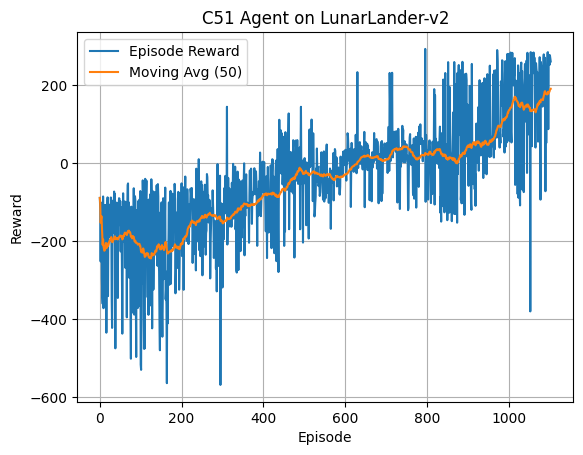

: 

In [ ]:
def train_c51():
    env = gym.make("LunarLander-v2")
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n
    agent = C51AgentTorch(obs_dim, n_actions)

    eps_start, eps_end, eps_decay = 1.0, 0.01, 100000
    epsilon = eps_start
    steps = 0

    episodes = 3000
    max_t = 500
    rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for t in range(max_t):
            action = agent.act(state, epsilon)
            next_state, reward, done, _, _ = env.step(action)

            agent.remember(state, action, reward, next_state, done)
            agent.train_step()

            state = next_state
            total_reward += reward

            steps += 1
            epsilon = max(eps_end, eps_start - steps / eps_decay)

            if done:
                break

        rewards.append(total_reward)
        avg = np.mean(rewards[-50:])
        print(f"Ep {ep} | R: {total_reward:.1f} | Avg50: {avg:.1f} | ε={epsilon:.3f}")

        if avg >= 200:
            print("Solved!")
            break

    plt.plot(rewards, label='Episode Reward')
    plt.plot([np.mean(rewards[max(0, i - 50):i + 1]) for i in range(len(rewards))], label='Moving Avg (50)')
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("C51 Agent on LunarLander-v2")
    plt.legend()
    plt.grid()
    plt.show()

if __name__ == "__main__":
    train_c51()


In [ ]:
# agent.model.save_weights("C51_online.weights.h5")

: 

In [ ]:
# env = gym.make("MountainCar-v0", render_mode="human")
for ep in range(5):
    state, _ = env.reset()
    total_r = 0
    for t in range(max_steps):
        action = agent.act(state, 0)
        next_state, reward, done, _, _ = env.step(action)

        state = next_state
        total_r += reward

        # ε-greedy decay
        steps += 1
        eps = max(epsilon_end, epsilon_start - steps / epsilon_decay)

        if done:
            break
    print(f"Episode {ep:4d} | return: {total_r:7.2f} | ε={eps: .3f}")

Episode    0 | return: -500.00 | ε= 0.630
Episode    1 | return: -500.00 | ε= 0.620
Episode    2 | return: -500.00 | ε= 0.610
Episode    3 | return: -500.00 | ε= 0.600
Episode    4 | return: -500.00 | ε= 0.590
Episode    5 | return: -500.00 | ε= 0.580
Episode    6 | return: -500.00 | ε= 0.570
Episode    7 | return: -500.00 | ε= 0.560
Episode    8 | return: -500.00 | ε= 0.550
Episode    9 | return: -500.00 | ε= 0.540
Episode   10 | return: -500.00 | ε= 0.530
Episode   11 | return: -500.00 | ε= 0.520
Episode   12 | return: -500.00 | ε= 0.510
Episode   13 | return: -500.00 | ε= 0.500


KeyboardInterrupt: 